# CME538 - Introduction to Data Science

## Assignment 3 - Data Cleaning and Text Analysis

### Learning Objectives

After completing this assignment, you should be able to:

- Import and inspect data stored in JSON format.
- Transform nested and semi-structured data into Pandas DataFrames.
- Identify and address duplicate, missing, inconsistent, and incorrectly typed data.
- Parse Unix timestamps and work with timezone-aware datetime data.
- Use Pandas string methods to clean and transform text data.
- Reshape and merge data to support text-based analysis.
- Create clear visualizations to compare patterns across groups.
- Apply a lexicon-based approach to estimate text sentiment.
- Interpret results while recognizing limitations of simple sentiment-analysis methods.
- Write clear, concise, and reproducible data-cleaning and analysis code.

### Submission Guidelines

You may add additional cells for exploratory or scratch work while completing the assignment. Before submitting:

- Remove unnecessary scratch cells and outputs.
- Keep only the code and output needed to answer each question.
- Do not display entire DataFrames or large outputs unless explicitly requested.
- Use the variable names specified in each question.
- Report written answers clearly in the designated answer cells.
- Restart the kernel and run the notebook from beginning to end to ensure that all cells execute without errors.

### Marking Breakdown

| Component | Points |
|---|---:|
| Question 1 | 1 |
| Question 2 | 1 |
| Question 3 | 2 |
| Question 4 | 2 |
| Question 5 | 2 |
| Question 6 | 1 |
| Question 7a-7d | 4 |
| Question 8a-8d | 4 |
| Question 9 | 1 |
| Question 10 | 2 |
| Question 11 | 2 |
| Question 12 | 3 |
| Question 13a-13b | 2 |
| Code Quality | 3 |
| **Total** | **30** |

### Code Quality

Code quality will be assessed across the complete notebook.

| Level | Points | Description |
|---|---:|---|
| **Developing** | 1 | Code produces the required results but may be difficult to follow, unnecessarily repetitive, poorly organized, or include excessive output. |
| **Competent** | 2 | Code is organized and readable, uses appropriate Python and Pandas operations, and produces concise, relevant outputs. |
| **Strong** | 3 | Code is clear, concise, well organized, and reproducible; uses Python and Pandas effectively; avoids unnecessary operations and output; and executes successfully from beginning to end. |

## Notebook Setup

In [ ]:
# Import required libraries
import os
import json

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Import course utilities
import utils

# Overview

This assignment uses a historical dataset of posts from the `@realDonaldTrump` Twitter account between January 1, 2016 and December 31, 2017.

The data are provided in five JSON files. Each file contains posts associated with a particular device type, including iPhone and Android devices. The dataset includes information such as the post text, timestamp, number of favorites and retweets, and whether the post is a retweet.

In this assignment, you will use the dataset to practice importing, cleaning, transforming, and analyzing semi-structured data. You will examine temporal and textual patterns in the posts and investigate whether those patterns differ across device types.

The assignment concludes with a simple lexicon-based text analysis in which words are assigned positive or negative scores. This provides an introduction to quantitative text analysis while also illustrating some of the limitations of representing language using simple numerical rules.

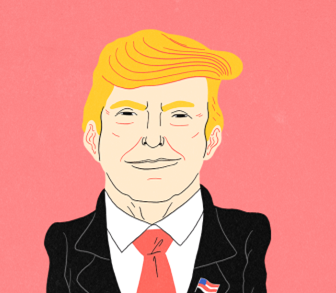
<center>Courtesy of FiveThirtyEight</center>

## Question 1 - Identifying the Data Files

Use `os.listdir()` to inspect the contents of the assignment directory.

Create a variable named `assignment_files` containing only the filenames that end with `.json`.

Sort the filenames alphabetically so that the result is reproducible.

In [ ]:
# Identify the JSON files in the assignment directory
assignment_files = ...

# Display and verify the result
print(f"Q1 Answer - Number of JSON files: {len(assignment_files)}")
print(assignment_files)

---

## Question 2 - Loading and Inspecting JSON

Load `trump_tweets_01-01-2016_31-12-2016_android.json` using the `json` library.

Store the parsed JSON data in a variable named `file_temp`.

Inspect the first two records to understand the structure of the data.

In [ ]:
# Load the JSON file
with open("trump_tweets_01-01-2016_31-12-2016_android.json", "r") as file:
    file_temp = ...

# Preview the first two records
file_temp[:2]

In [ ]:
# Display basic information about the imported data
print(f"Q2 Answer - Number of records: {len(file_temp)}")
print(f"Object type: {type(file_temp).__name__}")
print(f"Record type: {type(file_temp[0]).__name__}")

---

## Question 3 - Understanding the JSON Records

Each item in `file_temp` is a dictionary representing one tweet. Each tweet record contains six fields:

- `date`
- `favorites`
- `id`
- `isRetweet`
- `retweets`
- `text`

Inspect the first record to determine the value and Python data type associated with each field.

In [ ]:
# Inspect the first tweet record
first_record = file_temp[0]

for key, value in first_record.items():
    print(f"{key}: {value!r} ({type(value).__name__})")

#### Question 3 - Answer

| Field | Description | Data type |
|---|---|---|
| `date` | **[Your answer here]** | **[Your answer here]** |
| `favorites` | **[Your answer here]** | **[Your answer here]** |
| `id` | **[Your answer here]** | **[Your answer here]** |
| `isRetweet` | **[Your answer here]** | **[Your answer here]** |
| `retweets` | **[Your answer here]** | **[Your answer here]** |
| `text` | **[Your answer here]** | **[Your answer here]** |

---

## Question 4 - Combining the Tweet Files

The five JSON files contain tweet records from different time periods and devices. To analyze all tweets together, combine the records from all five files into a single list.

The device used to post each tweet is stored in the filename rather than in the JSON record itself. The device name is the final word before `.json`.

For example:

`trump_tweets_01-01-2016_31-12-2016_android.json`

corresponds to the device `android`.

Create a variable named `tweets` containing all tweet dictionaries from the files in `assignment_files`.

Add a new key named `device` to each tweet dictionary containing either `android` or `iphone`. Device names should be lowercase.

In [ ]:
# Create an empty list for the combined tweet records
tweets = []

# Load each JSON file and add the device to each tweet
for filename in assignment_files:
    device = ...
    
    with open(filename, "r") as file:
        file_tweets = ...
    
    for tweet in file_tweets:
        ...
    
    tweets.extend(file_tweets)

# Preview the first two records
utils.json_print(tweets[:2])

In [ ]:
# Verify the combined tweet records
print(f"Q4 Answer - Number of tweet records: {len(tweets)}")
print(f"Devices: {sorted(set(tweet['device'] for tweet in tweets))}")

---

## Question 5 - Creating and Cleaning the Tweet DataFrame

Convert the combined `tweets` list into a Pandas DataFrame.

Because the tweet records were collected from multiple files, duplicate tweets may be present. Remove duplicate rows based on the `id` column, keeping one copy of each tweet.

Reset the DataFrame index after removing duplicates.

In [ ]:
# Convert the tweet records to a DataFrame
tweets = ...

# Remove duplicate tweet IDs and reset the index
tweets = ...

# Preview the cleaned DataFrame
tweets.head()

In [ ]:
# Verify the cleaned DataFrame
print(f"Q5 Answer - Number of rows: {tweets.shape[0]}")
print(f"Number of columns: {tweets.shape[1]}")
print(f"Duplicate tweet IDs: {tweets['id'].duplicated().sum()}")
print(f"Devices: {sorted(tweets['device'].unique())}")

---

## Question 6 - Tweet Frequency by Device

Create a bar chart showing the number of tweets posted from each device.

Your plot should:

- show one bar for each device,
- label the x-axis as `Device`,
- label the y-axis as `Number of Tweets`, and
- include an appropriate title.

In [ ]:
# Create a bar chart of tweet frequency by device
...

# Display the tweet counts for verification
device_counts = tweets["device"].value_counts()

print("Q6 Answer - Tweet counts by device:")
print(device_counts)

## Question 7 - Tweet Activity Over Time

Next, we will examine how tweeting activity from Android and iPhone changed over the period covered by the dataset.

The raw `date` field contains a Unix timestamp. Before analyzing activity over time, we need to determine the timestamp units and convert the values into timezone-aware datetime objects.

### Question 7a - Identifying the Timestamp Units

The `date` column contains Unix timestamps. Unix timestamps represent elapsed time since January 1, 1970, but the stored values may be expressed in seconds, milliseconds, or other units.

Inspect a value from `tweets["date"]` and determine the units used in this dataset.

In [ ]:
# Inspect a sample timestamp
sample_timestamp = tweets.loc[0, "date"]

print(f"Sample timestamp: {sample_timestamp}")

#### Question 7a - Answer

The Unix timestamps are stored in **[Your answer here]**.

---

### Question 7b - Converting to UTC Datetime

Use `pd.to_datetime()` to convert the values in `tweets["date"]` to timezone-aware UTC datetime objects.

Store the result in a new column named `datetime_utc`.

In [ ]:
# Convert the Unix timestamps to UTC datetimes
tweets["datetime_utc"] = ...

# Preview the result
tweets[["date", "datetime_utc"]].head()

In [ ]:
# Verify the datetime conversion
print(f"Q7b Answer - Data type: {tweets['datetime_utc'].dtype}")
print(f"Earliest datetime: {tweets['datetime_utc'].min()}")
print(f"Latest datetime: {tweets['datetime_utc'].max()}")

---

### Question 7c - Setting the DataFrame Index

Set the index of the `tweets` DataFrame to the `id` column.

In [ ]:
# Set the tweet ID as the DataFrame index
tweets = ...

# Preview the result
tweets.head()

In [ ]:
# Verify the index
print(f"Q7c Answer - Index name: {tweets.index.name}")
print(f"Index is unique: {tweets.index.is_unique}")

---

### Question 7d - Visualizing Tweet Activity Over Time

Use `sns.histplot()` to compare the distribution of Android and iPhone tweets over time.

Create a single figure that:

- overlays the histogram distributions for both devices,
- displays a KDE curve for each device,
- uses `datetime_utc` on the x-axis,
- distinguishes Android and iPhone using `hue`, and
- includes appropriate axis labels and a title.

Use transparency so that overlapping histogram bars remain visible.

In [ ]:
# Create an overlaid histogram and KDE plot by device
...

plt.xlabel("Date")
plt.ylabel("Number of Tweets")
plt.title("Tweet Activity Over Time by Device")
plt.show()

In [ ]:
# Verification - do not modify
monthly_counts = (
    tweets
    .groupby([
        tweets["datetime_utc"].dt.tz_localize(None).dt.to_period("M"),
        "device"
    ])
    .size()
    .rename("tweet_count")
    .reset_index()
)

peak_months = monthly_counts.loc[
    monthly_counts.groupby("device")["tweet_count"].idxmax()
]

print("Q7d Answer - Peak month by device:")
print(peak_months)

---

## Question 8 - Daily Tweeting Patterns

Next, we will examine whether tweeting activity from Android and iPhone followed different patterns throughout the day.

Because `datetime_utc` is stored in UTC, first convert the timestamps to US Eastern time, which better represents the local time associated with the locations discussed in this analysis.

### Question 8a - Converting to Eastern Time

Convert `datetime_utc` from UTC to the `America/New_York` time zone.

This time zone automatically accounts for both Eastern Standard Time (EST) and Eastern Daylight Time (EDT).

Store the result in a new column named `datetime_et`.

In [ ]:
# Convert UTC timestamps to US Eastern time
tweets["datetime_et"] = ...

# Preview the result
tweets[["datetime_utc", "datetime_et"]].head()

In [ ]:
# Verify the time-zone conversion
print(f"Q8a Answer - Time zone: {tweets['datetime_et'].dt.tz}")

### Question 8b - Creating a Time-of-Day Variable

Create a new column named `hour` representing the time of day each tweet was posted in Eastern time.

Represent the hour as a decimal value so that minutes and seconds are retained.

For example:

- 6:00 AM corresponds to `6.0`
- 6:30 AM corresponds to `6.5`
- 9:00 PM corresponds to `21.0`

You can calculate decimal hour using:

`hour + minute / 60 + second / 3600`

In [ ]:
# Calculate the decimal hour of each tweet
tweets["hour"] = ...

# Preview the result
tweets[["datetime_et", "hour"]].head()

In [ ]:
# Verify the range of the hour variable
print(f"Q8b Answer - Minimum hour: {tweets['hour'].min():.2f}")
print(f"Maximum hour: {tweets['hour'].max():.2f}")

### Question 8c - Tweeting Patterns by Device

Use `sns.kdeplot()` to compare the distribution of posting times for Android and iPhone tweets.

Create a single plot showing both devices.

Your plot should:

- use `hour` on the x-axis,
- distinguish Android and iPhone using `hue`,
- display the full 24-hour period from 0 to 24,
- include appropriate axis labels and a title, and
- include a legend identifying the devices.

In [ ]:
# Plot the distribution of posting times by device
...

plt.xlim(0, 24)
plt.xlabel("Hour of Day (Eastern Time)")
plt.ylabel("Density")
plt.title("Tweeting Patterns by Time of Day")
plt.show()

In [ ]:
# Verification - do not modify
median_hour = tweets.groupby("device")["hour"].median()

print("Q8c Answer - Median posting hour by device:")
print(median_hour.round(2))

---

### Question 8d - Comparing Devices Before 2017

The use of the two devices changed during 2017, which may affect the device distributions observed above.

To make a cleaner comparison, restrict the analysis to tweets posted before January 1, 2017.

Create a DataFrame named `tweets_2016` containing only tweets before January 1, 2017 in Eastern Time, then create another KDE plot comparing the time-of-day distributions for Android and iPhone.

Use the same axis limits, labels, and general formatting as Question 8c.

In [ ]:
# Filter tweets to dates before January 1, 2017
tweets_2016 = ...

# Plot posting-time distributions for 2016
...

plt.xlim(0, 24)
plt.xlabel("Hour of Day (Eastern Time)")
plt.ylabel("Density")
plt.title("Tweeting Patterns by Time of Day - 2016")
plt.show()

In [ ]:
# Verification - do not modify
median_hour_2016 = tweets_2016.groupby("device")["hour"].median()

print("Q8d Answer - Median posting hour by device in 2016:")
print(median_hour_2016.round(2))

---

# 3. Lexicon-Based Text Analysis

In this section, you will construct a simple sentiment score for each tweet using word-level polarity values from the VADER lexicon.

The provided `vader_lexicon.txt` file assigns a polarity score to individual words and expressions. Positive values indicate more positive sentiment, while negative values indicate more negative sentiment.

For this assignment, we will use a simplified lexicon-based approach:

1. clean and tokenize each tweet,
2. match each token to the lexicon,
3. assign unmatched words a polarity of 0, and
4. sum the word-level polarity values for each tweet.

This is **not the complete VADER sentiment algorithm**. The full VADER method also accounts for linguistic features such as negation, capitalization, punctuation, intensifiers, and word order. The simplified approach used here is intended to practice data cleaning, reshaping, merging, and aggregation.

---

## Question 9 - Loading the Sentiment Lexicon

Read `vader_lexicon.txt` into a Pandas DataFrame named `lexicon`.

The file is tab-delimited. Retain only:

- the word or expression, which should become the DataFrame index, and
- its polarity score, stored in a column named `polarity`.

The remaining columns in the source file are not required.

In [ ]:
# Load the VADER word-level polarity lexicon
lexicon = ...

# Preview the result
lexicon.head()

In [ ]:
# Verification - do not modify
print(f"Q9 Answer - Lexicon entries: {lexicon.shape[0]}")
print(f"Columns: {lexicon.columns.tolist()}")
print(f"Index name: {lexicon.index.name}")

---

## Question 10 - Cleaning Tweet Text

Prepare the tweet text for matching against the lexicon.

Create a new column named `text_clean` that:

1. converts the tweet text to lowercase, and
2. replaces punctuation characters with spaces.

Use the provided `punctuations` string when removing punctuation.

Do not overwrite the original `text` column.

In [ ]:
punctuations = '!"#$%&\'()*+,-./:;<=>?@[\\]^_`{|}~“”'

In [ ]:
# Clean the tweet text
tweets["text_clean"] = ...

In [ ]:
# Verification - do not modify
sample_id = "814958820980039681"

print("Q10 Answer - Sample cleaned tweet:")
print(tweets.loc[sample_id, "text_clean"])

---

## Question 11 - Creating a Word Lookup Table

Convert the cleaned tweet text into a word-level lookup table.

Create a DataFrame named `word_lookup` with:

- one row for each word in each tweet,
- the tweet `id`, and
- a column named `word` containing the individual token.

Use Pandas string and reshaping methods rather than manually iterating over every tweet.

In [ ]:
# Convert tweets into a word-level lookup table
word_lookup = ...

# Preview the result
word_lookup.head()

In [ ]:
# Verification - do not modify
sample_id = "814958820980039681"
sample_words = word_lookup.loc[
    word_lookup["id"] == sample_id,
    "word"
].tolist()

print(f"Q11 Answer - Number of words in sample tweet: {len(sample_words)}")
print(f"First 10 words: {sample_words[:10]}")

---

## Question 12 - Calculating Tweet Polarity

Use `word_lookup` and `lexicon` to calculate a polarity score for each tweet.

Your workflow should:

1. add the lexicon polarity score to each word in `word_lookup`,
2. assign a polarity of `0` to words that are not present in the lexicon,
3. sum the word-level polarity values for each tweet, and
4. add the resulting tweet-level polarity score to the `tweets` DataFrame as a column named `polarity`.

In [ ]:
# Add word-level polarity scores
word_lookup = ...

# Replace missing polarity values with 0
word_lookup["polarity"] = ...

# Calculate total polarity for each tweet
polarity = ...

# Add tweet-level polarity to the tweets DataFrame
tweets = ...

# Preview the result
tweets[["text", "polarity"]].head()

In [ ]:
# Verification - do not modify
print(f"Q12 Answer - Missing polarity values: {tweets['polarity'].isna().sum()}")
print(f"Minimum polarity: {tweets['polarity'].min():.2f}")
print(f"Maximum polarity: {tweets['polarity'].max():.2f}")

---

### Exploring High and Low Polarity Tweets

Run the cells below to inspect tweets with the lowest and highest polarity scores.

Remember that these scores come from a simplified word-summing method and should not be interpreted as a complete measure of sentiment.

In [ ]:
# Display tweets with the lowest polarity scores
tweets.nsmallest(5, "polarity")[["text", "polarity"]]

In [ ]:
# Display tweets with the highest polarity scores
tweets.nlargest(5, "polarity")[["text", "polarity"]]

---

## Question 13 - Polarity and Keywords

Finally, explore whether tweets containing different keywords have different distributions of polarity scores.

### Question 13a - Comparing `nytimes` and `fox`

Create a single plot comparing the distribution of polarity scores for tweets containing:

- `nytimes`
- `fox`

Keyword matching should be case-insensitive.

Your plot should:

- show both distributions in the same figure,
- clearly distinguish between the two keywords,
- label the x-axis and y-axis,
- include an appropriate title, and
- include a legend.

In [ ]:
# Select tweets containing each keyword
nytimes_tweets = ...
fox_tweets = ...

# Plot the polarity distributions
...

plt.xlabel("Polarity Score")
plt.ylabel("Density")
plt.title("Polarity of Tweets Containing 'nytimes' and 'fox'")
plt.legend()
plt.show()

In [ ]:
# Verification - do not modify
print(f"Q13a Answer - 'nytimes' tweets: {nytimes_tweets.shape[0]}")
print(f"'fox' tweets: {fox_tweets.shape[0]}")
print(f"Mean 'nytimes' polarity: {nytimes_tweets['polarity'].mean():.2f}")
print(f"Mean 'fox' polarity: {fox_tweets['polarity'].mean():.2f}")

---

### Question 13b - Exploring Your Own Keywords

Choose two additional keywords that produce an interesting comparison of tweet polarity.

Create a single plot comparing the polarity distributions for tweets containing your two selected keywords.

Use the same general plotting requirements as Question 13a.

Briefly state the two keywords you selected and describe one observation from the resulting distributions.

In [ ]:
# Define two keywords
keyword_1 = ...
keyword_2 = ...

# Select tweets containing each keyword
keyword_1_tweets = ...
keyword_2_tweets = ...

# Plot the polarity distributions
...

plt.xlabel("Polarity Score")
plt.ylabel("Density")
plt.title("Polarity Comparison for Selected Keywords")
plt.legend()
plt.show()

In [ ]:
# Verification - do not modify
print(f"Q13b Answer - '{keyword_1}' tweets: {keyword_1_tweets.shape[0]}")
print(f"'{keyword_2}' tweets: {keyword_2_tweets.shape[0]}")
print(f"Mean '{keyword_1}' polarity: {keyword_1_tweets['polarity'].mean():.2f}")
print(f"Mean '{keyword_2}' polarity: {keyword_2_tweets['polarity'].mean():.2f}")

#### Question 13b - Answer

- Keyword 1: **[Your answer here]**
- Keyword 2: **[Your answer here]**

Briefly describe one interesting difference or similarity between the two polarity distributions:

**[Your answer here]**

---

## Before You Submit

You have completed **Assignment 3 - Data Cleaning and Text Analysis**.

Before submitting:

- Review your answers for completeness and accuracy.
- Remove unnecessary scratch cells and outputs.
- Keep only the code and output needed to answer each question.
- Do not modify cells labelled `# Verification - do not modify`.
- Ensure all requested variables use the specified names.
- Confirm that all required plots are displayed and include appropriate titles, axis labels, and legends.
- Confirm that all written-response questions are completed.
- Do not display entire DataFrames or unnecessarily large outputs.
- Restart the kernel and run the notebook from beginning to end to ensure all cells execute without errors.
- Review your code for clarity, readability, and unnecessary operations.

**Submit your completed html and notebook to Quercus.**